# Imports

In [1]:
import numpy as np
import pandas as pd
import xml
import xml.etree.ElementTree as ET

# Parsing Util

In [2]:
def parse(element: xml.etree.ElementTree.Element):
    """
    Parses an xml element into a dictionary.
    """
    d = {}
    if not element.text or '\t' in element.text:
        for child in element:
            if child.tag in d:
                if type(d[child.tag]) is list:
                    d[child.tag].append(parse(child))
                else:
                    d[child.tag] = [d[child.tag], parse(child)]
            else:
                d[child.tag] = parse(child)
    else:
        return element.text
    
    return d

    

In [3]:
import os
names = list(set([name.split('.')[0] for name in os.listdir('data')]))

In [4]:
import random
import cv2

def sample_data(ids: list[tuple[str, dict, np.ndarray]]):
    """
    Parses the xml files and loads the images for the given ids
    """
    sample = []
    for id in ids:
        tree = xml.etree.ElementTree.parse(f'data/{id}.xml')
        root = tree.getroot()
        annotation = parse(root)
        image = cv2.imread(f'data/{id}.jpg')
        sample.append((id, image, annotation))
    
    return sample

# Visualization

In [5]:
from matplotlib import pyplot as plt
from matplotlib import patches

def visualize_sample(sample):
    """
    Plot the images with the bounding boxes for the given sample
    """
    num_samples = len(sample)
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 4))
    for i, (id, image, annotation) in enumerate(sample):
        print(annotation)
        ax = axes[i]
        ax.imshow(image)
        if "object" in annotation:
            if type(annotation["object"]) is not list:
                annotation["object"] = [annotation["object"]]
            for obj in annotation["object"]:
                x = int(obj["bndbox"]["xmin"])
                y = int(obj["bndbox"]["ymin"])
                w = int(obj["bndbox"]["xmax"]) - x
                h = int(obj["bndbox"]["ymax"]) - y
                rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
                # label the box
                ax.text(x, y, obj["name"], color='r')
                ax.add_patch(rect)
        ax.set_title(id)
        ax.axis("off")


In [6]:
def visualize_random_sample(names: list[str], num_samples: int):
    """
    Visualizes a random sample of the given data
    """
    ids = random.sample(names, num_samples)
    sample = sample_data(ids)
    visualize_sample(sample)

{'folder': 'images_28_aprile', 'filename': 'lower_829585.jpg', 'path': '/home/francesco/Desktop/dataset_28_aprile/images_28_aprile/lower_829585.png', 'source': {'database': 'Unknown'}, 'size': {'width': '320', 'height': '240', 'depth': '3'}, 'segmented': '0', 'object': [{'name': 'robot', 'pose': 'Unspecified', 'truncated': '1', 'difficult': '0', 'bndbox': {'xmin': '230', 'ymin': '1', 'xmax': '319', 'ymax': '201'}}, {'name': 'centerspot', 'pose': 'Unspecified', 'truncated': '0', 'difficult': '0', 'bndbox': {'xmin': '43', 'ymin': '87', 'xmax': '145', 'ymax': '144'}}]}
{'folder': 'images_28_aprile', 'filename': 'upper_460615.jpg', 'path': '/home/francesco/Desktop/dataset_28_aprile/images_28_aprile/upper_460615.png', 'source': {'database': 'Unknown'}, 'size': {'width': '640', 'height': '480', 'depth': '3'}, 'segmented': '0', 'object': [{'name': 'goalspot', 'pose': 'Unspecified', 'truncated': '0', 'difficult': '0', 'bndbox': {'xmin': '443', 'ymin': '69', 'xmax': '467', 'ymax': '84'}}, {'nam

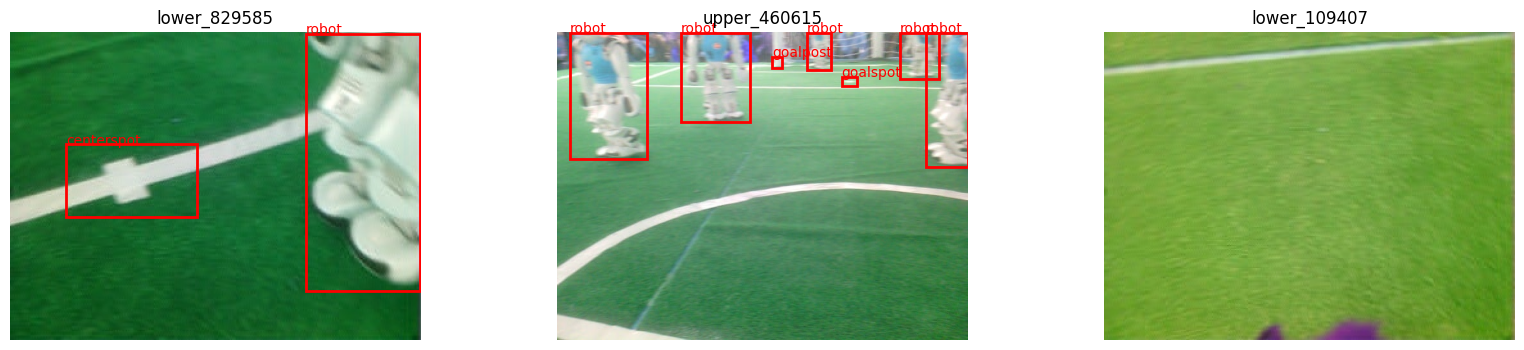

In [7]:
visualize_random_sample(names, 3)

# Line Segmentation 

In [8]:
def segment_line(image):
    """
    Segments the white lines and curves on the green field from the image using color thresholding, edge detection, and Hough Line Transform.
    """
    # Convert the image to HSV color space
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # Define the range for white color in HSV
    lower_white = np.array([0, 0, 200])
    upper_white = np.array([180, 30, 255])
    
    # Threshold the HSV image to get only white colors
    mask = cv2.inRange(hsv, lower_white, upper_white)
    
    # Bitwise-AND mask and original image
    white_lines = cv2.bitwise_and(image, image, mask=mask)
    
    # Convert the result to grayscale
    gray = cv2.cvtColor(white_lines, cv2.COLOR_BGR2GRAY)
    
    # GaussianBlur to reduce noise and improve edge detection
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Canny edge detection
    edges = cv2.Canny(blurred, 50, 150)
    
    # Hough Line Transform to detect lines
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=50, minLineLength=100, maxLineGap=5)
    
    
    # Hough Line Transform to detect curves
    lines_curves = cv2.HoughLines(edges, 1, np.pi / 180, threshold=200)
    
    line_image = np.copy(image)
    
    if lines_curves is not None:
        for line in lines_curves:
            rho, theta = line[0]
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))
            cv2.line(line_image, (x1, y1), (x2, y2), (255, 0, 0), 2)
    
    if lines is not None:
        for line in lines:
            for x1, y1, x2, y2 in line:
                cv2.line(line_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    # Contour detection for curves
    contours, _ = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        if cv2.arcLength(contour, True) > 100:  # Filter small contours
            cv2.drawContours(line_image, [contour], -1, (0, 0, 255), 2)
    
    return line_image

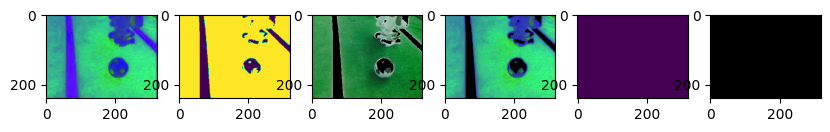

In [9]:
sample = sample_data(random.sample(names, 1))
id, image, annotation = sample[0]
line_segmented_image = segment_line(image)

# Convert the image to HSV color space
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Define the range for green color in HSV
lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])

# Threshold the HSV image to get only green colors
green_mask = cv2.inRange(hsv, lower_green, upper_green)

# Bitwise-AND mask and original image to get the green field
green_field = cv2.bitwise_and(image, image, mask=green_mask)

# Convert the green field to HSV color space
hsv_green_field = cv2.cvtColor(green_field, cv2.COLOR_BGR2HSV)
# Define the range for white color in HSV
lower_white = np.array([0, 0, 200])
upper_white = np.array([180, 30, 255])

# Threshold the HSV image to get only white colors on the green field
white_mask = cv2.inRange(hsv_green_field, lower_white, upper_white)

# Bitwise-AND mask and green field image to get the white lines on the green field
white_lines_on_green = cv2.bitwise_and(green_field, green_field, mask=white_mask)

plt.figure(figsize=(10, 5))
plt.subplot(1, 6, 1)
plt.imshow(hsv)

plt.subplot(1,6,2)
plt.imshow(green_mask)

plt.subplot(1,6,3)
plt.imshow(green_field)

plt.subplot(1,6,4)
plt.imshow(hsv_green_field)

plt.subplot(1,6,5)
plt.imshow(white_mask)

plt.subplot(1,6,6)
plt.imshow(white_lines_on_green)


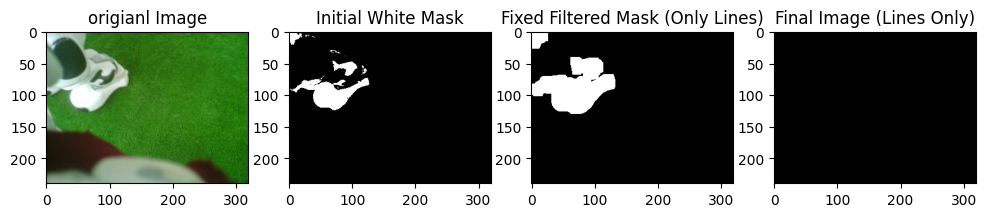

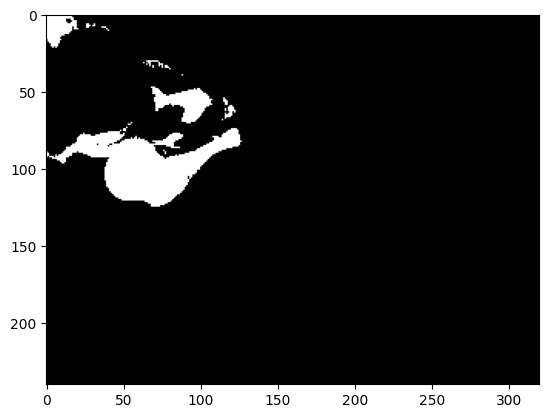

In [10]:
sample = sample_data(random.sample(names, 1))
id, image, annotation = sample[0]
line_segmented_image = segment_line(image)

# Convert the image to HSV color space
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Step 2: Extract Green Field Mask
lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])
green_mask = cv2.inRange(hsv, lower_green, upper_green)

green_mask_convert = cv2.bitwise_not(green_mask)

# Step 3: Extract White Lines on Green Field
lower_white = np.array([0, 0, 200])
upper_white = np.array([180, 30, 255])
white_mask = cv2.inRange(hsv, lower_white, upper_white)

# Step 4: Bitwise-AND to Keep Only White Lines on the Green Field
white_lines = cv2.bitwise_and(white_mask, white_mask, mask=green_mask_convert)

# Step 5: Contour Filtering Based on Shape (Fix Applied)
contours, _ = cv2.findContours(white_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
filtered_mask = np.zeros_like(white_lines)

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = float(w) / h 

    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    if 100 < area < 50000 and perimeter > 50:
        cv2.drawContours(filtered_mask, [cnt], -1, 255, thickness=cv2.FILLED)
        
# Apply Morphological Dilation to Reconnect Lines
kernel = np.ones((5,5), np.uint8)
filtered_mask = cv2.dilate(filtered_mask, kernel, iterations=3)

# Step 6: Use Hough Transform to Detect Straight/Curved Lines
edges = cv2.Canny(filtered_mask, 50, 150)
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=50, minLineLength=30, maxLineGap=20)

line_mask = np.zeros_like(filtered_mask)
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_mask, (x1, y1), (x2, y2), 255, thickness=5)  # **Fix: Increase thickness**

# Step 7: Combine with Original Image (Only Keep the White Lines)
sharp_lines = cv2.bitwise_and(image, image, mask=line_mask)

# Display Results
plt.figure(figsize=(12, 6))
plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("origianl Image")

plt.subplot(1, 4, 2)
plt.imshow(white_mask, cmap='gray')
plt.title("Initial White Mask")

plt.subplot(1, 4, 3)
plt.imshow(filtered_mask, cmap='gray')
plt.title("Fixed Filtered Mask (Only Lines)")

plt.subplot(1, 4, 4)
plt.imshow(cv2.cvtColor(sharp_lines, cv2.COLOR_BGR2RGB))
plt.title("Final Image (Lines Only)")

plt.show()

# plt.imshow(green_mask_convert, cmap='gray')
plt.imshow(white_lines, cmap='gray')


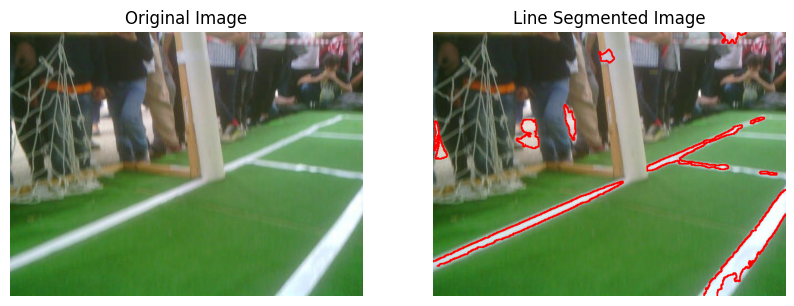

In [11]:
sample = sample_data(random.sample(names, 1))
id, image, annotation = sample[0]
line_segmented_image = segment_line(image)

# Display the original and line-segmented images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(line_segmented_image, cv2.COLOR_BGR2RGB))
plt.title("Line Segmented Image")
plt.axis("off")

plt.show()

To segment only the white lines and curves on the green field while ignoring complex shapes such as humans, balls, and other robots, you can refine the process by focusing on the characteristics of the lines and curves. Here is an updated approach:

1. Extract the green field mask.
2. Extract the white lines mask.
3. Combine the masks to isolate the white lines on the green field.
4. Apply morphological operations to clean up the mask.
5. Use contour filtering to remove complex shapes.
6. Use the Hough Transform to detect lines and curves.

Here is the updated code:

